# Lending Club EDA -- F3 -- Univariate, Distributional & Visual Analysis

**Status: built.** See the cell map below for what's actually in this notebook.

## What this notebook covers

Full summary statistics and small-multiples charts for every retained numeric and categorical feature, plus targeted deep dives on the fields whose shape stood out most (annual_inc's extreme skew, revol_bal/dti tails).

## Where this fits

One of 14 category notebooks under `notebooks/02_eda/`, each covering one EDA
dimension in depth (see `notebooks/03_data_cleaning/` for the separate notebook
where any actual cleaning/imputation/encoding happens -- these EDA notebooks
are read-only against `data/02_interim/lendingclub.duckdb` and never modify
or clean the data themselves). Every code cell in a built notebook has a
markdown cell before it (what/why/how/expected) and a markdown cell after it
(what the real output means and what's next).


## Cell map

| # | What it does |
|---|---|
| 1 | Connect; summary statistics for all 20 retained numeric features |
| 2 | Small-multiples histogram grid, all 20 numeric features |
| 3 | Deep dive: `annual_inc`'s extreme skew |
| 4 | Deep dive: `revol_bal` / `dti` tails |
| 5 | Summary table for all 7 retained categorical features |
| 6 | Small-multiples bar-chart grid, all 7 categorical features |

## Cell 1 -- summary statistics, all 20 retained numeric features

**What / why:** One comprehensive stats table -- mean, median, std, skew,
min, max, missing% -- covering every retained numeric column at once.

**Expect:** a mix of roughly-symmetric fields and heavily right-skewed
ones; skew above roughly 2-3 usually signals a log transform would help.

In [1]:
import os, duckdb, pandas as pd, numpy as np
con = duckdb.connect(r"../../data/02_interim/lendingclub.duckdb", read_only=True)
ASSETS_TABLES = "../../data/04_assets/tables"
ASSETS_PLOTS = "../../data/04_assets/plots"
os.makedirs(ASSETS_TABLES, exist_ok=True)
os.makedirs(ASSETS_PLOTS, exist_ok=True)

rows = []
for c in ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl']:
    r = con.sql(f'''
        SELECT avg(TRY_CAST("{c}" AS DOUBLE)) mean,
               median(TRY_CAST("{c}" AS DOUBLE)) median,
               stddev(TRY_CAST("{c}" AS DOUBLE)) std,
               skewness(TRY_CAST("{c}" AS DOUBLE)) skew,
               min(TRY_CAST("{c}" AS DOUBLE)) min,
               max(TRY_CAST("{c}" AS DOUBLE)) max,
               1 - count(TRY_CAST("{c}" AS DOUBLE))*1.0/count(*) pct_missing
        FROM windowed
    ''').fetchone()
    rows.append((c,) + r)
numeric_summary = pd.DataFrame(rows, columns=["column","mean","median","std","skew","min","max","pct_missing"])
pd.set_option("display.width", 140)
print(numeric_summary.round(2).to_string(index=False))
numeric_summary.to_csv(os.path.join(ASSETS_TABLES, "eda03_numeric_summary.csv"), index=False)


              column      mean   median       std  skew     min         max  pct_missing
           loan_amnt  14547.10 12000.00   8687.45  0.76 1000.00    40000.00         0.00
            int_rate     13.25    12.74      4.77  0.72    5.32       30.99         0.00
          annual_inc  76600.63 65000.00  70083.49 47.23    0.00 10999200.00         0.00
                 dti     18.51    17.87     10.86 27.13   -1.00      999.00         0.00
      fico_range_low    694.75   685.00     31.02  1.35  660.00      845.00         0.00
         delinq_2yrs      0.33     0.00      0.90  5.51    0.00       39.00         0.00
      inq_last_6mths      0.64     0.00      0.93  1.73    0.00        6.00         0.00
            open_acc     11.72    11.00      5.50  1.30    0.00       90.00         0.00
             pub_rec      0.23     0.00      0.63 11.35    0.00       86.00         0.00
           revol_bal  16482.43 11260.00  22812.31 13.97    0.00  2904836.00         0.00
          revol_util 

**What the output shows:** skew ranges from roughly symmetric to extreme --
`annual_inc` is most right-skewed at
47.2. 8 of 20 fields have
|skew| over 3 and are candidates for a log transform.

**Next:** seeing the actual shapes as histograms -- a stats table alone
can't distinguish a smoothly skewed distribution from a spiky or bimodal
one.

## Cell 2 -- small multiples: every numeric feature's distribution

**What / why:** A 4x5 grid of histograms, one per retained numeric feature,
clipped to the 1st-99th percentile for display only (not the underlying
data) so extreme values don't compress the rest of the histogram.

**Expect:** right-skewed shapes matching cell 1's skew numbers, a couple
closer to normal (`fico_range_low`, `dti`), and spikes at zero for
count-type fields.

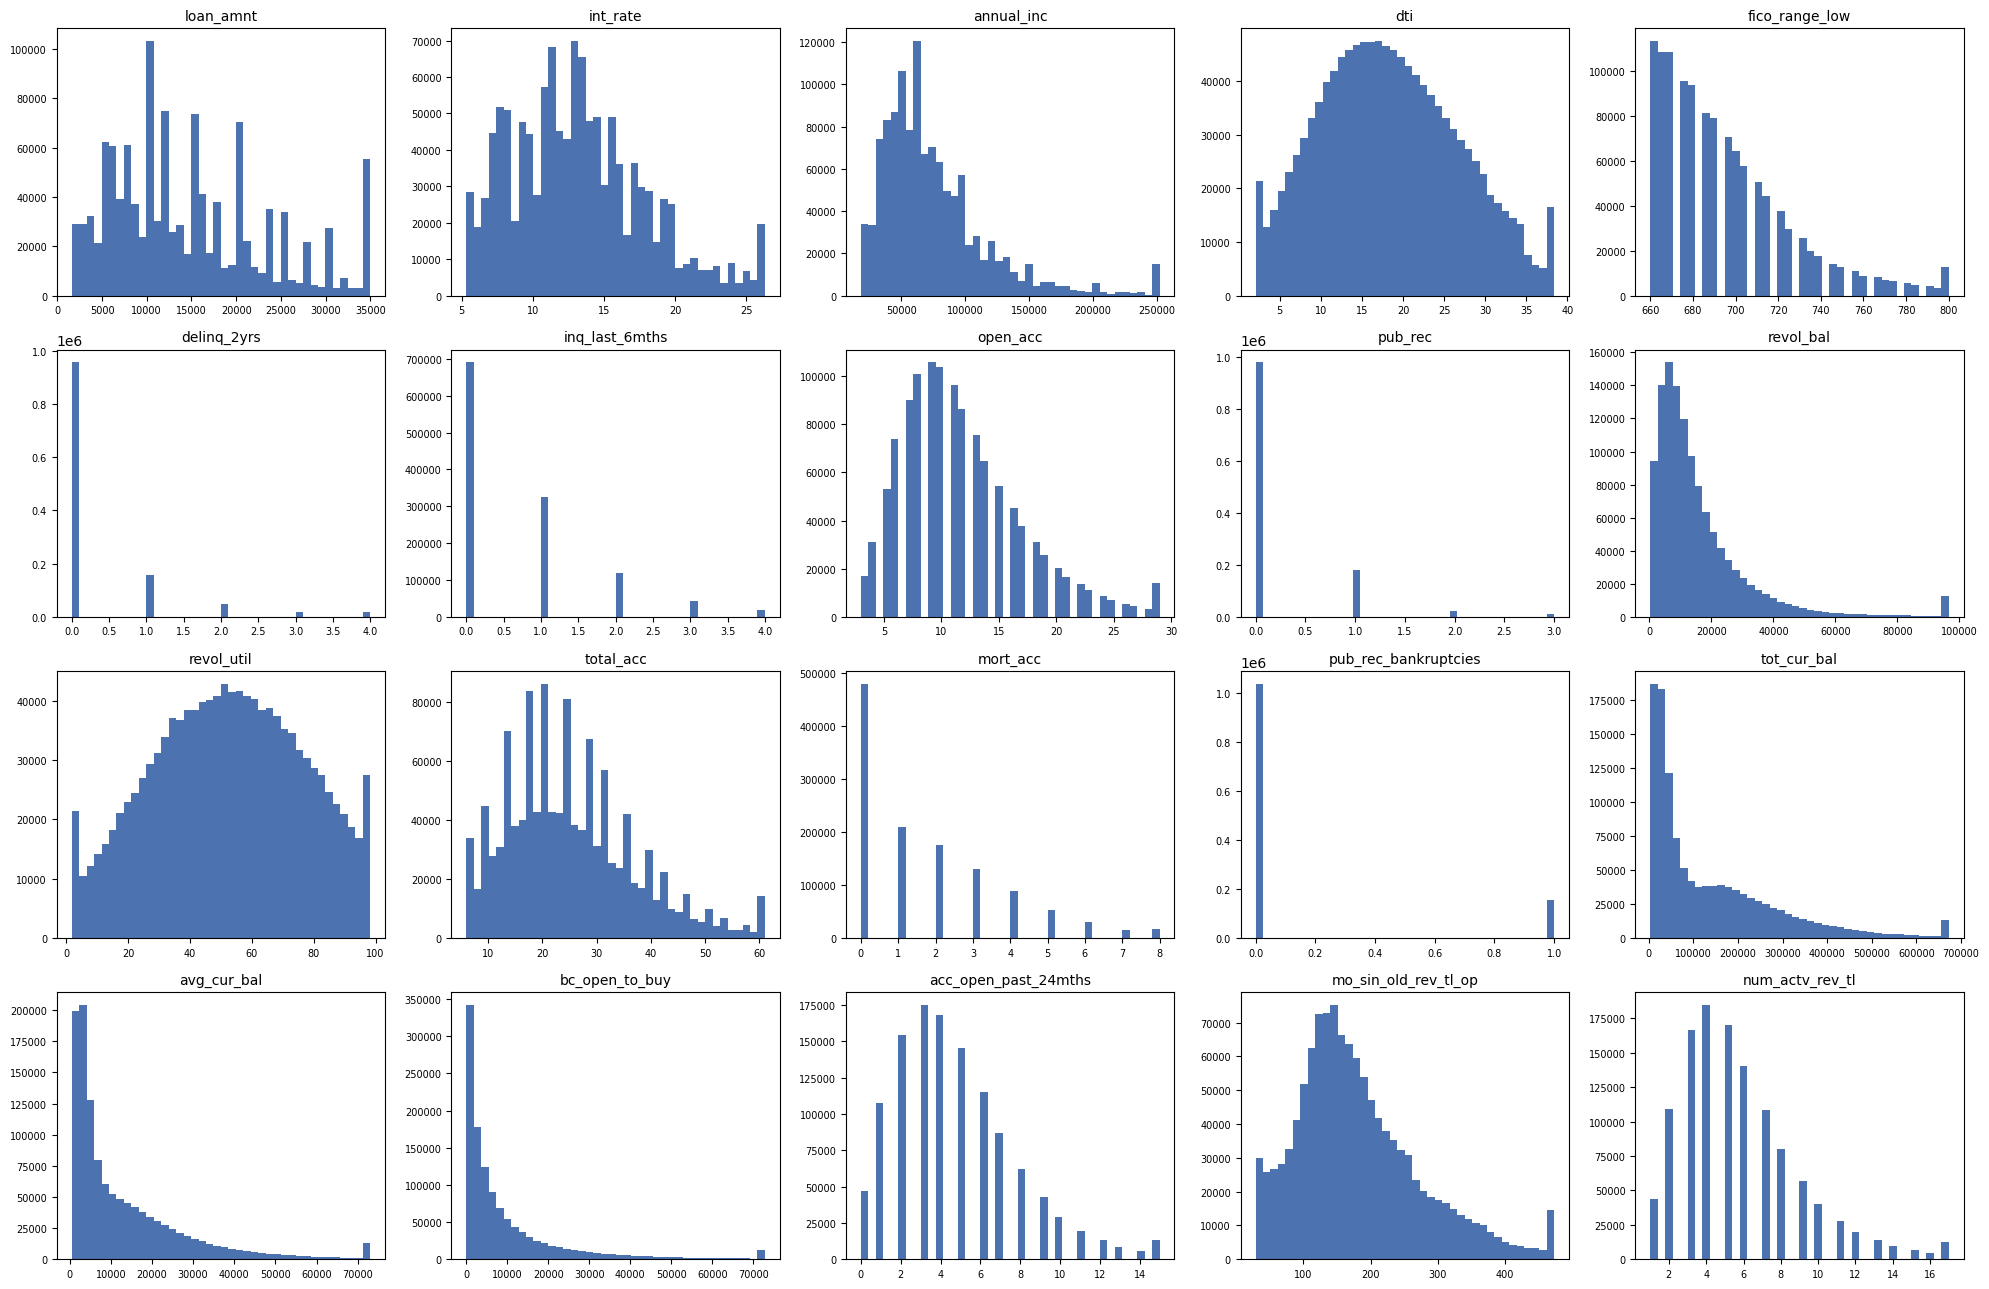

In [2]:
import matplotlib.pyplot as plt
cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl']
fig, axes = plt.subplots(4, 5, figsize=(20, 13))
for ax, c in zip(axes.flat, cols):
    vals = con.sql(f'SELECT TRY_CAST("{c}" AS DOUBLE) v FROM windowed WHERE TRY_CAST("{c}" AS DOUBLE) IS NOT NULL').df()["v"]
    lo, hi = vals.quantile([0.01, 0.99])
    ax.hist(vals.clip(lo, hi), bins=40, color="#4C72B0")
    ax.set_title(c, fontsize=10)
    ax.tick_params(labelsize=7)
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda03_c02_numeric_small_multiples.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:** the grid confirms the skew numbers visually --
income/balance fields (annual_inc, revol_bal, tot_cur_bal, avg_cur_bal,
bc_open_to_buy) show a long right tail even after percentile clipping;
count-type fields (delinq_2yrs, pub_rec, pub_rec_bankruptcies,
inq_last_6mths) spike sharply at 0. `fico_range_low` and `dti` are the
closest to symmetric of the set.

**Next:** two fields stood out enough to deserve an individual closer look
-- `annual_inc` for its extreme skew, and `revol_bal`/`dti` for their tail
behavior.

## Cell 3 -- deep dive: annual_inc's extreme skew

**What / why:** `annual_inc` has by far the highest skew in the retained
set. Checking the actual top values and comparing raw vs. log-transformed
histograms before trusting a log transform.

**Expect:** a small number of very high but plausible self-reported
incomes, and a log-transformed histogram much closer to symmetric.

top 10 annual_inc values:
         v
10999200.0
 9550000.0
 9522972.0
 9500000.0
 9225000.0
 9000000.0
 8900060.0
 8706582.0
 8700000.0
 8500021.0

skew(annual_inc): 47.2


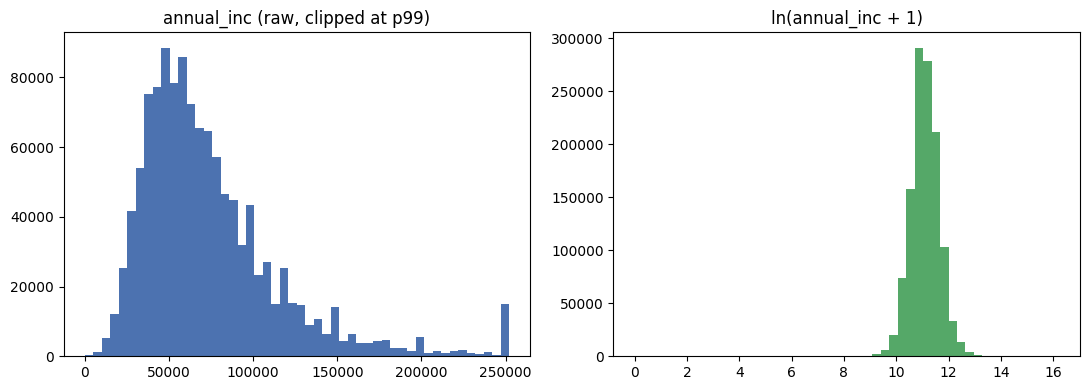

In [3]:
top_incomes = con.sql('''
    SELECT TRY_CAST(annual_inc AS DOUBLE) v FROM windowed
    WHERE TRY_CAST(annual_inc AS DOUBLE) IS NOT NULL
    ORDER BY v DESC LIMIT 10
''').df()
print("top 10 annual_inc values:")
print(top_incomes.to_string(index=False))
top_incomes.to_csv(os.path.join(ASSETS_TABLES, "eda03_top_incomes.csv"), index=False)
skew_val = con.sql("SELECT skewness(TRY_CAST(annual_inc AS DOUBLE)) FROM windowed").fetchone()[0]
print(f"\nskew(annual_inc): {skew_val:.1f}")

import matplotlib.pyplot as plt
vals = con.sql("SELECT TRY_CAST(annual_inc AS DOUBLE) v FROM windowed WHERE TRY_CAST(annual_inc AS DOUBLE) IS NOT NULL").df()["v"]
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].hist(vals.clip(upper=vals.quantile(0.99)), bins=50, color="#4C72B0")
axes[0].set_title("annual_inc (raw, clipped at p99)")
axes[1].hist(np.log1p(vals), bins=50, color="#55A868")
axes[1].set_title("ln(annual_inc + 1)")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda03_c03_annual_inc_deep_dive.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:** top values top out around
$10,999,200, plausible for genuine (unverified,
self-reported) high earners rather than typos. Skew is 47.2.
The log-transformed histogram looks close to symmetric, confirming a log
transform does real work here, not just cosmetic rescaling.

**Next:** one more numeric deep dive on `revol_bal`/`dti` before moving to
the categorical features.

## Cell 4 -- deep dive: revol_bal and dti tails

**What / why:** Checking `revol_bal` (dollars) and `dti` (a ratio) with
boxplots specifically for how far their tails extend, plus IQR fence
violation counts.

**Expect:** `revol_bal` shows the same long tail as other balance fields;
`dti`'s tail is real but not extreme.

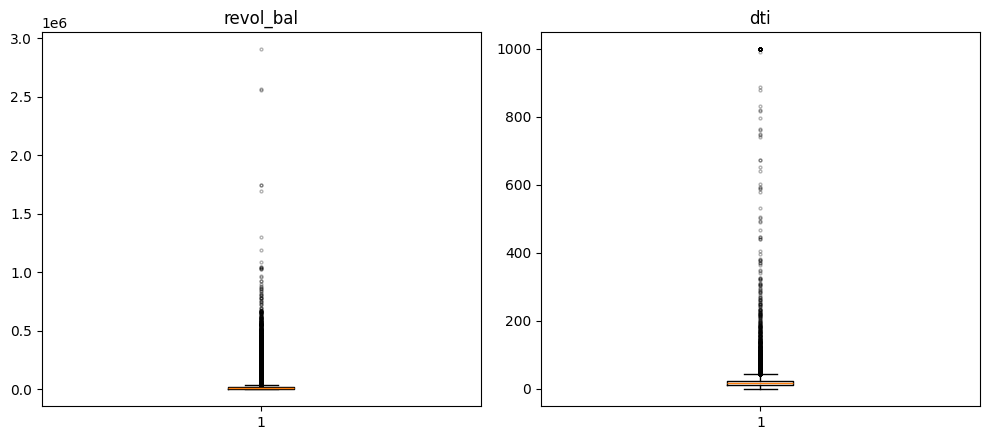

revol_bal: Q1=6071.0 Q3=19951.0 upper fence=40771.0, 71,116 rows above fence
dti: Q1=12.0 Q3=24.4 upper fence=42.9, 4,043 rows above fence


In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
for ax, c in zip(axes, ["revol_bal", "dti"]):
    vals = con.sql(f'SELECT TRY_CAST("{c}" AS DOUBLE) v FROM windowed WHERE TRY_CAST("{c}" AS DOUBLE) IS NOT NULL').df()["v"]
    ax.boxplot(vals, vert=True, flierprops={"markersize": 2, "alpha": 0.3})
    ax.set_title(c)
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda03_c04_revol_bal_dti_tails.png"), dpi=110, bbox_inches="tight")
plt.show()

for c in ["revol_bal", "dti"]:
    q1, q3 = con.sql(f'SELECT quantile_cont(TRY_CAST("{c}" AS DOUBLE),0.25), quantile_cont(TRY_CAST("{c}" AS DOUBLE),0.75) FROM windowed').fetchone()
    iqr = q3 - q1
    hi = q3 + 1.5*iqr
    n_above = con.sql(f'SELECT count(*) FROM windowed WHERE TRY_CAST("{c}" AS DOUBLE) > {hi}').fetchone()[0]
    print(f"{c}: Q1={q1:.1f} Q3={q3:.1f} upper fence={hi:.1f}, {n_above:,} rows above fence")


**What the output shows:**
```
revol_bal: Q1=6071.0 Q3=19951.0 upper fence=40771.0, 71,116 rows above fence
dti: Q1=12.0 Q3=24.4 upper fence=42.9, 4,043 rows above fence
```
Both fields have a real tail beyond the IQR fence, but the values themselves
(tens of thousands of dollars of revolving debt, dti in the 30s-40s) look
like genuine risk-relevant extremes, not data-entry errors.

**Next:** numeric profiling done. Moving to the 7 retained categorical
features.

## Cell 5 -- summary table, all 7 retained categorical features

**What / why:** Cardinality, the modal category, its share of rows, and
missingness for every retained categorical column in one table.

**Expect:** `addr_state` highest cardinality (~50 states), `term` lowest
(2 values); a couple of fields with one dominant category.

In [5]:
rows = []
for c in ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state']:
    r = con.sql(f'''
        SELECT count(DISTINCT "{c}") n_distinct,
               1 - count("{c}")*1.0/count(*) pct_missing
        FROM windowed
    ''').fetchone()
    mode_row = con.sql(f'''
        SELECT "{c}" mode_val, count(*) n FROM windowed
        WHERE "{c}" IS NOT NULL GROUP BY 1 ORDER BY n DESC LIMIT 1
    ''').fetchone()
    n_total = con.sql("SELECT count(*) FROM windowed").fetchone()[0]
    rows.append((c, r[0], mode_row[0], mode_row[1]/n_total, r[1]))
cat_summary = pd.DataFrame(rows, columns=["column","n_distinct","mode","mode_share","pct_missing"])
print(cat_summary.round(3).to_string(index=False))
cat_summary.to_csv(os.path.join(ASSETS_TABLES, "eda03_cat_summary.csv"), index=False)


             column  n_distinct               mode  mode_share  pct_missing
               term           2          36 months       0.758        0.000
              grade           7                  B       0.290        0.000
         emp_length          11          10+ years       0.334        0.059
     home_ownership           5           MORTGAGE       0.497        0.000
verification_status           3    Source Verified       0.398        0.000
            purpose          14 debt_consolidation       0.587        0.000
         addr_state          51                 CA       0.144        0.000


**What the output shows:** cardinality runs from
2 (`term`) to
51 (`addr_state`). The
most concentrated field is `term`,
where the mode covers 75.8% of rows.

**Next:** seeing the actual category distributions as bar charts, all 7 at
once.

## Cell 6 -- small multiples: every categorical feature's distribution

**What / why:** A bar chart per categorical feature (top 10 categories for
high-cardinality ones), so shape is visible directly rather than reduced to
one mode-share number.

**Expect:** `term`/`grade`/`home_ownership` clean and interpretable;
`addr_state` a long tail behind a few large states; `emp_length` clustered
at round bucket values.

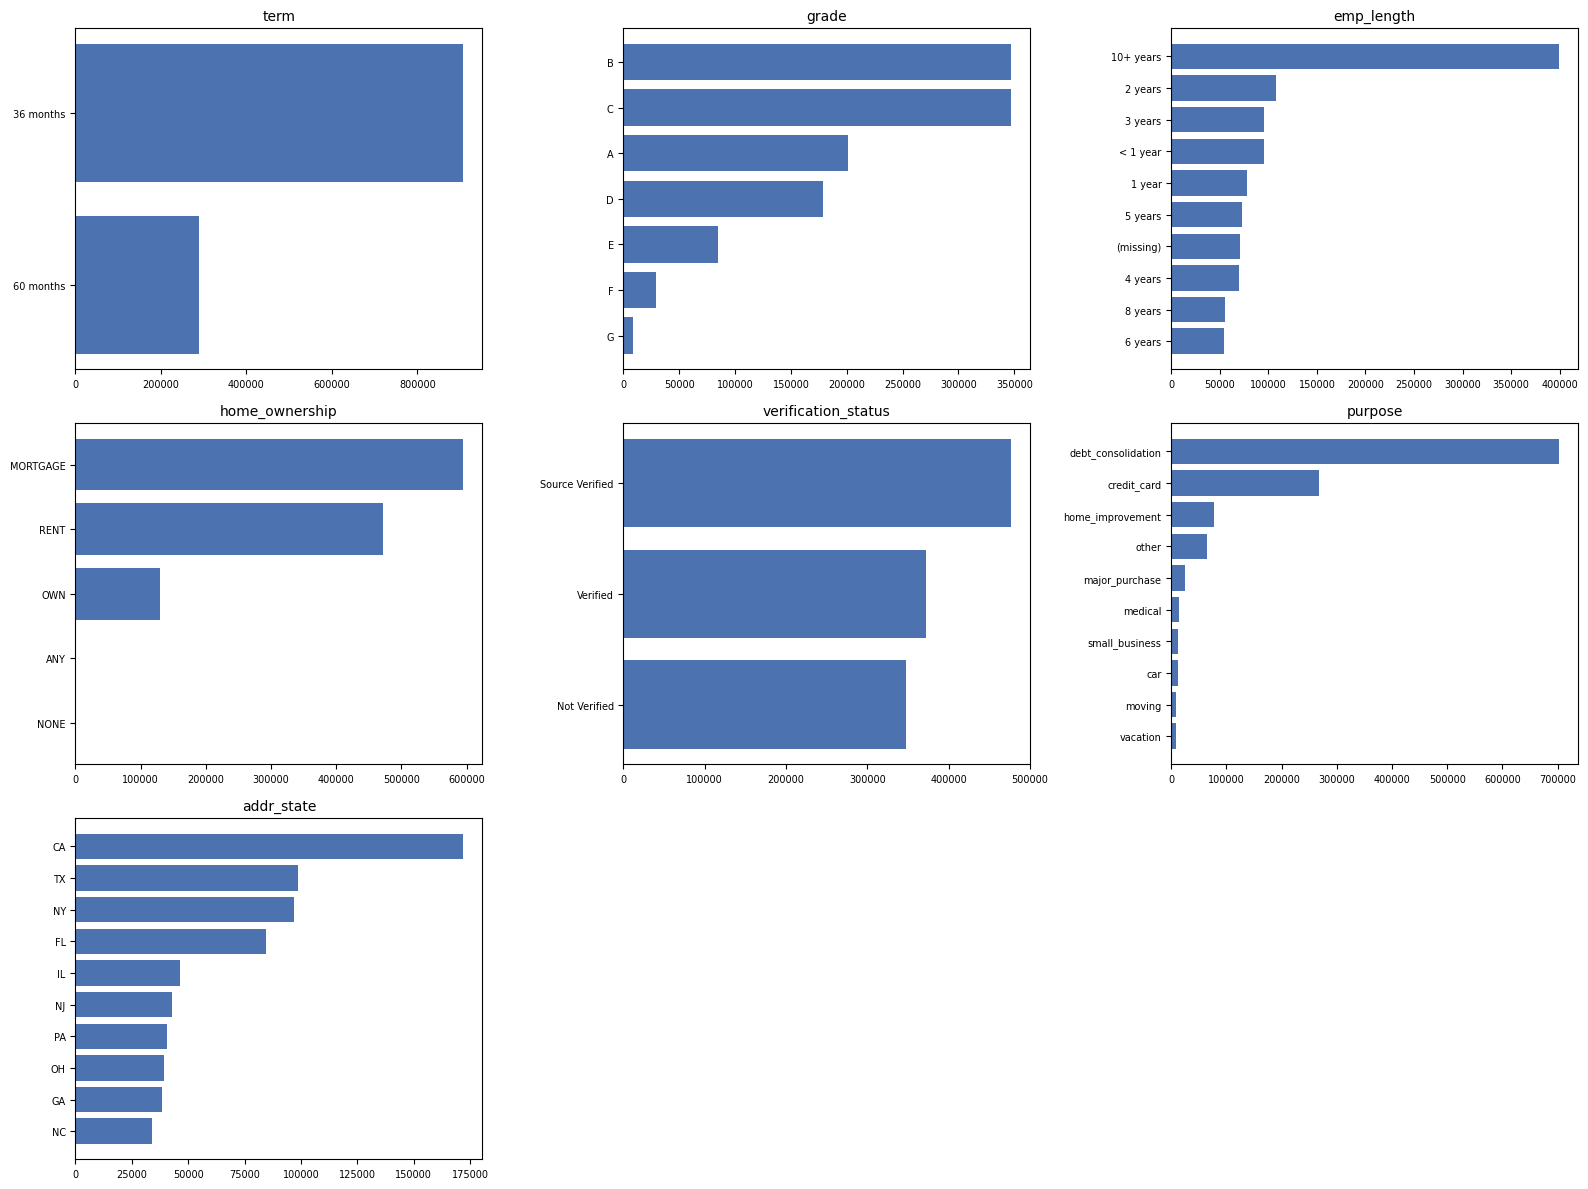

In [6]:
import matplotlib.pyplot as plt
cols = ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, c in zip(axes.flat, cols):
    vc = con.sql(f'''
        SELECT COALESCE("{c}",'(missing)') v, count(*) n FROM windowed
        GROUP BY 1 ORDER BY n DESC LIMIT 10
    ''').df()
    ax.barh(vc["v"][::-1], vc["n"][::-1], color="#4C72B0")
    ax.set_title(c, fontsize=10)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(cols):]:
    ax.axis("off")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda03_c06_categorical_small_multiples.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:** the grid confirms expectations -- `term`/`grade`
clean, `home_ownership` dominated by MORTGAGE/RENT, `addr_state`'s tail
behind CA/TX/NY/FL, `emp_length` clustering at `10+ years`, `purpose`
dominated by debt_consolidation/credit_card with higher-risk categories in a
thin tail worth remembering when reading bad-rate charts later (small base,
noisier estimate).

**Next:** `04_bivariate_multivariate_relationships.ipynb` relates every one
of these profiled features to `is_bad`.